# 🛫 Prévision des Retards Aériens — Notebook MLflow
**Projet PPML- FlyOnTime — 6 plus grands aéroports français**


### Configuration & Imports

In [1]:
import pandas as pd
import os
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from pandas.api.types import is_datetime64_any_dtype
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import mlflow

### Connexion MLflow

In [2]:
# --- 1. CONFIGURATION SERVEUR ---
MLFLOW_REMOTE_URI = "https://stoneray-ppml-mlflow.hf.space/"
mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)

PRENOM = "Ludo"
TYPE_MODEL = "XGBoost" # Change ici : "XGBoost" ou "RandomForest"

EXPERIMENT_NAME = f"FlyOnTime_classif"
RUN_NAME        = f"{TYPE_MODEL}_classifier"
MODEL_NAME_TAG  = f"{TYPE_MODEL}_classifier_{PRENOM}"
REGISTERED_NAME = "FlyOnTime_classif"
ALIAS_NAME      = "challenger"

while mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Connecté à : {MLFLOW_REMOTE_URI}")
print(f"🚀 Run : {RUN_NAME} | Tag : {MODEL_NAME_TAG}")

✅ Connecté à : https://stoneray-ppml-mlflow.hf.space/
🚀 Run : XGBoost_classifier | Tag : XGBoost_classifier_Ludo


### Chargement des données

**Source :** AWS S3 (format Parquet)

**Datasets :**
- `df_train` → données historiques pour l'entraînement
- `df_predict` → données d'avril 2026 pour la prédiction finale

In [3]:
import boto3

# Fonction pour récupérer mes fichiers sur le bucket S3 de l'équipe
def charger_data_s3(chemin_fichier):
    # Setup de la session avec mes accès
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    
    nom_bucket = os.getenv("BUCKET_EQUIPE")
    url_complete = f"s3://{nom_bucket}/{chemin_fichier}"
    
    print(f"Récupération du fichier : {chemin_fichier}...")
    
    
    if chemin_fichier.endswith('.csv'):
        return pd.read_csv(url_complete)
    else:
        return pd.read_parquet(url_complete)

# Chargement depuis S3
df_train = charger_data_s3("datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv")
df_predict = charger_data_s3("datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv")

# Je vérifie le format
print(f"Format Train   : {df_train.shape}")
print(f"Format Predict : {df_predict.shape}")

Récupération du fichier : datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv...


C:\Users\surel\AppData\Local\Temp\ipykernel_34756\744087605.py:19: DtypeWarning: Columns (64,65,67,76,80,82,84,86) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(url_complete)


Récupération du fichier : datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv...
Format Train   : (94378, 96)
Format Predict : (4063, 96)


In [4]:
# Aperçu rapide des colonnes disponibles
print("Colonnes df_train :")
print(df_train.columns.tolist())
print("Colonnes df_predict :")
print(df_predict.columns.tolist())
print("---------------------------")
print("Aperçu df_train :")
df_train.head()


Colonnes df_train :
['flight_date', 'movement_date', 'flight_number', 'airline', 'airport_origin', 'airport_destination', 'terminal_departure', 'terminal_arrival', 'scheduled_departure', 'scheduled_arrival', 'estimated_departure', 'estimated_arrival', 'actual_departure', 'actual_arrival', 'actual_source_departure', 'actual_source_arrival', 'departure_delay_min', 'departure_advance_min', 'arrival_delay_min', 'arrival_advance_min', 'status', 'movement_type', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'cloud_base_dep', 'visibility_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunder

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


### On voit que la première ligne est inutile

In [5]:
print(df_train.iloc[0])
df = df_train.iloc[1:].reset_index(drop=True)
df_predict = df_predict.iloc[1:].reset_index(drop=True)


display(df_train.head())
print("-----------------------------------------------------------------------")
display(df_predict.head())

flight_date                             DATE_GENERATION
movement_date                       2026-04-17 03:31:48
flight_number                                       NaN
airline                                             NaN
airport_origin                                      NaN
                                           ...         
nombre_departs_destination                          NaN
nombre_arrivees_destination                         NaN
somme_depart_arrivee_destination                    NaN
congestion_destination                              NaN
retard arrivée                                      NaN
Name: 0, Length: 96, dtype: object


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


-----------------------------------------------------------------------


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2026-04-17,2026-04-17,AF 6212,Air France,ORY,NCE,2,2,2026-04-17 12:35+02:00,2026-04-17 14:05+02:00,...,NaN,550.0,540.0,1090.0,1.0,179.0,177.0,356.0,0.0,0.0
1,2026-04-17,2026-04-17,AF 7300,Air France,CDG,NCE,2F,2,2026-04-17 06:45+02:00,2026-04-17 08:15+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
2,2026-04-17,2026-04-17,AF 7301,Air France,NCE,CDG,2,2F,2026-04-17 09:05+02:00,2026-04-17 10:40+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0
3,2026-04-17,2026-04-17,AF 7302,Air France,CDG,NCE,2F,2,2026-04-17 07:15+02:00,2026-04-17 08:50+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
4,2026-04-17,2026-04-17,AF 7303,Air France,NCE,CDG,2,2F,2026-04-17 09:45+02:00,2026-04-17 11:20+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0


### --- Vérification des doublons ---
Normalement, un numéro de vol sur une même journée, c'est unique. 
Si j'en ai plusieurs, c'est qu'il y a un bug dans l'extraction.

In [6]:
# --- VÉRIFICATION DES DOUBLONS (Train & Predict) ---

# 1. Check sur les données d'entraînement
doublons_train = df_train[df_train.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"⚠️ Doublons dans le Train : {len(doublons_train)}")

# 2. Check sur les données futures (histoire d'être sûr)
doublons_predict = df_predict[df_predict.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"🔍 Doublons dans le Predict : {len(doublons_predict)}")

# Si j'ai un doute sur le futur, je regarde
if len(doublons_predict) > 0:
    print("Aperçu des doublons 'Futur' :")
    display(doublons_predict.sort_values(by=["flight_number", "flight_date"]).head(6))

⚠️ Doublons dans le Train : 1572


🔍 Doublons dans le Predict : 92
Aperçu des doublons 'Futur' :


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
162,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 12:35+02:00,2026-04-17 13:45+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
163,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 17:00+02:00,2026-04-17 18:10+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
1360,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 12:35+02:00,2026-04-19 13:45+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1361,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 16:40+02:00,2026-04-19 17:50+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1924,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 12:35+02:00,2026-04-20 13:45+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0
1925,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 17:00+02:00,2026-04-20 18:10+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0


Nous avons identifié que les doublons apparents ne correspondent pas à des escales, mais à deux lignes complémentaires décrivant un même vol : l’une pour le départ et l’autre pour l’arrivée. Il ne faut donc pas supprimer ces lignes ni les traiter séparément, car cela entraînerait une perte d’information et un biais dans le modèle. La bonne approche consiste à regrouper ces lignes pour reconstruire un vol complet en une seule observation, en combinant les informations de départ et d’arrivée (par exemple via un groupby et des agrégations adaptées).

In [7]:
# --- ANALYSE DES DOUBLONS (TRAIN & PREDICT) ---

# Définition des colonnes qui identifient un vol unique
cles_doublons = ["flight_number", "flight_date", "airport_origin", "airport_destination"]

# 1. Analyse pour le TRAIN
masque_train = df_train.duplicated(subset=cles_doublons, keep=False)
vols_doubles_train = df_train[masque_train]
vols_uniques_train = df_train[~masque_train]

# 2. Analyse pour le PREDICT
masque_predict = df_predict.duplicated(subset=cles_doublons, keep=False)
vols_doubles_predict = df_predict[masque_predict]
vols_uniques_predict = df_predict[~masque_predict]

# --- VÉRIFICATION DES THÉORIES ---
print(f"📊 TRAIN   : {len(vols_doubles_train)} lignes en doublons ({len(vols_doubles_train)//2} vols)")
print(vols_doubles_train["movement_type"].value_counts())

print(f"\n📊 PREDICT : {len(vols_doubles_predict)} lignes en doublons ({len(vols_doubles_predict)//2} vols)")
print(vols_doubles_predict["movement_type"].value_counts())

# Si les volumes Departure/Arrival sont quasi identiques, on confirme la structure "vols coupés en deux"

📊 TRAIN   : 1480 lignes en doublons (740 vols)
movement_type
departure    741
arrival      739
Name: count, dtype: int64

📊 PREDICT : 80 lignes en doublons (40 vols)
movement_type
departure    47
arrival      33
Name: count, dtype: int64


Il arrive que certain avions fassent plusieurs rotations par jour 
Quand on "recolle" le vol, on crée une seule ligne ultra-complète.
Avant (2 lignes) :
Ligne 1 : Vol AF1234 | Départ Paris | Vent 20km/h
Ligne 2 : Vol AF1234 | Arrivée Nice | Pluie | Retard 15min
Après (1 vol recollé) : Ligne Unique : Vol AF1234 | Départ Paris (Vent 20km/h) | Arrivée Nice (Pluie) | Retard 15min

In [8]:
# --- LA RÉPARATION (TRAIN & PREDICT) ---

def reparer_vols(df):
    # 1. Nettoyage de la ligne technique et conversion dates
    df = df.iloc[1:].reset_index(drop=True)
    dates_cols = ["flight_date", "scheduled_departure", "scheduled_arrival"]
    for c in dates_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    masque = df.duplicated(subset=cles, keep=False)
    
    vols_solo = df[~masque].copy()
    vols_a_reparer = df[masque].copy()
    
    dep = vols_a_reparer[vols_a_reparer["movement_type"] == "departure"].sort_values("scheduled_departure")
    arr = vols_a_reparer[vols_a_reparer["movement_type"] == "arrival"].sort_values("scheduled_arrival")

    dep["n_vol"] = dep.groupby(cles).cumcount()
    arr["n_vol"] = arr.groupby(cles).cumcount()
    
    df_reconstruit = pd.merge(dep, arr, on=cles + ["n_vol"], suffixes=('_dep', '_arr'))
    
    return pd.concat([vols_solo, df_reconstruit], ignore_index=True)

df_train_final = reparer_vols(df_train)
df_predict_final = reparer_vols(df_predict)

# --- BILAN ---
print(f"✅ TRAIN   : {len(df_train_final)} vols prêts.")
print(f"✅ PREDICT : {len(df_predict_final)} vols prêts.")

C:\Users\surel\AppData\Local\Temp\ipykernel_34756\2513086950.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors="coerce")
C:\Users\surel\AppData\Local\Temp\ipykernel_34756\2513086950.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors="coerce")


✅ TRAIN   : 93584 vols prêts.
✅ PREDICT : 4014 vols prêts.


### --- BILAN DE SANTÉ FINAL ---
 Je rajoute l'heure de départ prévue ('scheduled_departure') dans le filtre pour prendre en compte l'heure de départ.

In [9]:
colonnes_cles = ['flight_number', 'flight_date', 'scheduled_departure']
 
nb_train = df_train_final.duplicated(subset=colonnes_cles).sum()
nb_predict = df_predict_final.duplicated(subset=colonnes_cles).sum()
print(f"Bilan de santé Train   : {nb_train} vrais doublons.")
print(f"Bilan de santé Predict : {nb_predict} vrais doublons.")
if nb_train + nb_predict == 0:
    print("\n✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.")
else:
    print("\n⚠️ Attention, il reste encore des rescapés à checker.")

Bilan de santé Train   : 0 vrais doublons.
Bilan de santé Predict : 0 vrais doublons.

✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.


In [10]:
#%who DataFrame
#on travaille désormais sur df_train_final et df_predict_final, qui sont nos datasets réparés et prêts pour l'analyse et le modeling.

### On s'occupe des NaN 🫓

In [11]:
print(f"📏 Dimensions du TRAIN   : {df_train_final.shape} (Lignes, Colonnes)")
print(f"📏 Dimensions du PREDICT : {df_predict_final.shape} (Lignes, Colonnes)")

📏 Dimensions du TRAIN   : (93584, 281) (Lignes, Colonnes)
📏 Dimensions du PREDICT : (4014, 281) (Lignes, Colonnes)


In [12]:
def check_missing(df, name):
    print(f"\n🔍 ANALYSE : {name}")
    stats = (df.isna().mean() * 100).sort_values(ascending=False)
    stats_filtered = stats[stats > 0]
    if not stats_filtered.empty:
        print(stats_filtered.head(30))
    else:
        print("✅ Propre comme un sou neuf !")

check_missing(df_train_final, "TRAIN")
check_missing(df_predict_final, "PREDICT")


🔍 ANALYSE : TRAIN
Label Jour Ferié_arr      100.000000
cloud_base_arr_arr        100.000000
visibility_arr_arr        100.000000
visibility_dep_arr        100.000000
cloud_base_dep_arr        100.000000
visibility_arr_dep        100.000000
Label Jour Ferié_dep      100.000000
LABEL_TOULOUSE            100.000000
LABEL_TOULOUSE_arr        100.000000
cloud_base_dep_dep        100.000000
visibility_dep_dep        100.000000
cloud_base_arr            100.000000
LABEL_TOULOUSE_dep        100.000000
cloud_base_dep            100.000000
visibility_dep            100.000000
cloud_base_arr_dep        100.000000
visibility_arr            100.000000
LABEL_CDG_arr              99.998931
LABEL_CDG_dep              99.998931
LABEL_ORLY_arr             99.995726
LABEL_ORLY_dep             99.995726
LABEL_MARSEILLE_dep        99.976492
LABEL_MARSEILLE_arr        99.976492
LABEL_LYON_arr             99.973286
LABEL_LYON_dep             99.973286
LABEL_NICE_dep             99.961532
LABEL_NICE_arr     

In [13]:
def purger_et_voir(df, nom_dataset):
    print(f"\n--- 🗑️ NETTOYAGE : {nom_dataset} ---")
    colonnes_avant = set(df.columns)
    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    # On protège tout ce qui contient "delay" ou "retard"
    mots_cles_proteges = ['delay', 'retard', 'target'] 
    
    cols_a_garder = [c for c in df.columns if 
                     c.endswith(('_dep', '_arr')) or 
                     c in cles or 
                     any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_filtre = df[cols_a_garder].copy()
    
    seuil = 0.6 
    taux_nan = df_filtre.isnull().mean()
    cols_trop_vides = [c for c in taux_nan[taux_nan > seuil].index 
                       if not any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_final = df_filtre.drop(columns=cols_trop_vides)
    
    fantômes = colonnes_avant - set(cols_a_garder)
    print(f"👻 {len(fantômes)} colonnes sans suffixe supprimées.")
    print(f"🏜️ {len(cols_trop_vides)} colonnes > {seuil*100}% vides supprimées.")
    print(f"🛡️ Colonnes de retard préservées : {[c for c in df_final.columns if any(mot in c.lower() for mot in mots_cles_proteges)]}")
    
    return df_final.ffill().bfill()

# On relance
df_train_final = purger_et_voir(df_train_final, "TRAIN")
df_predict_final = purger_et_voir(df_predict_final, "PREDICT")


--- 🗑️ NETTOYAGE : TRAIN ---
👻 48 colonnes sans suffixe supprimées.
🏜️ 182 colonnes > 60.0% vides supprimées.
🛡️ Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_delay_min_arr', 'retard arrivée_arr']

--- 🗑️ NETTOYAGE : PREDICT ---
👻 48 colonnes sans suffixe supprimées.
🏜️ 182 colonnes > 60.0% vides supprimées.
🛡️ Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_delay_min_arr', 'retard arrivée_arr']


In [14]:
def scan_total_vides(df, name):
    print(f"\n🕵️ SCAN COMPLET : {name}")
    nans = df.isna().sum().sum()
    
    vides = (df == "").sum().sum()
    placeholders = ["none", "null", "unknown", "missing", "nan", "undefined"]
    text_vides = df.apply(lambda x: x.astype(str).str.lower().isin(placeholders)).sum().sum()
    infinites = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

    print(f"  - NaNs classiques      : {nans}")
    print(f"  - Textes vides ('' )   : {vides}")
    print(f"  - Mots-clés 'vides'    : {text_vides}")
    print(f"  - Valeurs infinies     : {infinites}")

scan_total_vides(df_train_final, "TRAIN")
scan_total_vides(df_predict_final, "PREDICT")


🕵️ SCAN COMPLET : TRAIN
  - NaNs classiques      : 0
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 0
  - Valeurs infinies     : 0

🕵️ SCAN COMPLET : PREDICT
  - NaNs classiques      : 24084
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 24084
  - Valeurs infinies     : 0


In [15]:
print("Columnes Train:", list(df_train_final.columns))
print("\nColumnes Predict:", list(df_predict_final.columns))
 
diff = set(df_train_final.columns) ^ set(df_predict_final.columns)
print(f"\n✅ Identiques : {not diff}" if not diff else f"⚠️ Différences : {diff}")

Columnes Train: ['flight_date', 'flight_number', 'airport_origin', 'airport_destination', 'departure_delay_min', 'arrival_delay_min', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr', 'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr', 'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr', 'has_precipitation_arr', 'fog_arr', 'humidity_arr', 'temperature_2m_arr', 'cloud_cover_arr', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_

### On définit la notion de retard

In [19]:
y_reg_arr = df_train_final['arrival_delay_min'].clip(lower=0)   # Cible : retard à l'arrivée
y_reg_dep = df_train_final['departure_delay_min'].clip(lower=0) # Cible : retard au départ

print(f"📊 Moyenne retard Arrivée : {y_reg_arr.mean():.2f} min")
print(f"📊 Moyenne retard Départ  : {y_reg_dep.mean():.2f} min")

📊 Moyenne retard Arrivée : 15.43 min
📊 Moyenne retard Départ  : 23.04 min


### MODELING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow
import mlflow.sklearn

# --- CONFIGURATION DES CONVENTIONS (Ludo) ---
PRENOM = "Ludo"
EXPERIMENT_NAME = "FlyOnTime_Regressor"
RUN_NAME = "RandomForest_Regressor"
MODEL_NAME_MLFLOW = f"{RUN_NAME}_{PRENOM}"
REGISTERED_NAME = f"{RUN_NAME}_registered"

mlflow.set_experiment(EXPERIMENT_NAME)


y_reg_arr = df_train_final['arrival_delay_min'].clip(lower=0)
y_reg_dep = df_train_final['departure_delay_min'].clip(lower=0)

cols_a_virer = [c for c in df_train_final.columns if any(x in c.lower() for x in ['delay', 'retard', 'target', 'time_dep', 'time_arr'])]
X_clean = df_train_final.drop(columns=cols_a_virer, errors='ignore').copy()

for col in X_clean.columns:
    if pd.api.types.is_datetime64_any_dtype(X_clean[col]) or X_clean[col].dtype == 'object':
        try:
            temp_date = pd.to_datetime(X_clean[col], errors='raise')
            X_clean[f"{col}_month"] = temp_date.dt.month
            X_clean[f"{col}_day"] = temp_date.dt.dayofweek
            X_clean[f"{col}_hour"] = temp_date.dt.hour
            X_clean = X_clean.drop(columns=[col])
        except:
            continue

cat_cols = X_clean.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_clean[cat_cols] = encoder.fit_transform(X_clean[cat_cols].astype(str))

X_clean = X_clean.fillna(-1)

X_train, X_test, y_reg_arr_train, y_reg_arr_test = train_test_split(X_clean, y_reg_arr, test_size=0.2, random_state=42)
_, _, y_reg_dep_train, y_reg_dep_test = train_test_split(X_clean, y_reg_dep, test_size=0.2, random_state=42)

with mlflow.start_run(run_name=RUN_NAME) as run:
    
    mlflow.set_tag("Prénom", PRENOM)
    mlflow.set_tag("user", PRENOM)
    
    
    n_est = 100
    m_depth = 12
    params = {"n_estimators": n_est, "max_depth": m_depth, "random_state": 42}
    mlflow.log_params(params)

    print(f"🚀 Lancement de l'entraînement par {PRENOM}...")

    model_reg_arr = RandomForestRegressor(**params, n_jobs=-1)
    model_reg_arr.fit(X_train, y_reg_arr_train)
    y_pred_arr = model_reg_arr.predict(X_test)
    mae_arr = mean_absolute_error(y_reg_arr_test, y_pred_arr)
    r2_arr = r2_score(y_reg_arr_test, y_pred_arr)
    mlflow.log_metric("mae_arrival", mae_arr)
    mlflow.log_metric("r2_arrival", r2_arr)

    model_reg_dep = RandomForestRegressor(**params, n_jobs=-1)
    model_reg_dep.fit(X_train, y_reg_dep_train)
    
    y_pred_dep = model_reg_dep.predict(X_test)
    mae_dep = mean_absolute_error(y_reg_dep_test, y_pred_dep)
    r2_dep = r2_score(y_reg_dep_test, y_pred_dep)
    mlflow.log_metric("mae_departure", mae_dep)
    mlflow.log_metric("r2_departure", r2_dep)

    mlflow.sklearn.log_model(model_reg_arr, f"{MODEL_NAME_MLFLOW}_arrival", registered_model_name=f"{REGISTERED_NAME}_arr")
    mlflow.sklearn.log_model(model_reg_dep, f"{MODEL_NAME_MLFLOW}_departure", registered_model_name=f"{REGISTERED_NAME}_dep")

    print(f"✅ Terminé ! MAE Arrivée: {mae_arr:.2f} | MAE Départ: {mae_dep:.2f}")
    print(f"🔗 ID de la run : {run.info.run_id}")

C:\Users\surel\AppData\Local\Temp\ipykernel_34756\2079222187.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_date = pd.to_datetime(X_clean[col], errors='raise')
C:\Users\surel\AppData\Local\Temp\ipykernel_34756\2079222187.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_date = pd.to_datetime(X_clean[col], errors='raise')
C:\Users\surel\AppData\Local\Temp\ipykernel_34756\2079222187.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_date = pd.to_datetime(X_clean[col], errors='raise')
C:\Users\surel\AppData\Local\Temp\ipykernel_34756\2079222187.py:30:

🚀 Lancement de l'entraînement par Ludo...


2026/04/20 13:26:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 13:26:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RandomForest_Regressor_registered_arr'.
2026/04/20 13:27:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest_Regressor_registered_arr, version 1
Created version '1' of model 'RandomForest_Regressor_registered_arr'.
2026/04/20 13:27:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 13:27:18 WARNING mlflow.sklearn: Saving

✅ Terminé ! MAE Arrivée: 10.10 | MAE Départ: 11.82
🔗 ID de la run : 370061ae8b8c495c97a3edd739389037
🏃 View run RandomForest_Regressor at: https://stoneray-ppml-mlflow.hf.space/#/experiments/13/runs/370061ae8b8c495c97a3edd739389037
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/13


In [78]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

indices_test = X_test.index
mouvement_test = np.where(df_train_final.loc[indices_test, 'airport_origin'] == 'CDG', '🛫 DÉPART', '🛬 ARRIVÉE')

pred_arr = model_reg_arr.predict(X_test)
pred_dep = model_reg_dep.predict(X_test)

resultats_comparaison = pd.DataFrame({
    'Mouvement': mouvement_test,
    'Réel': np.where(mouvement_test == '🛫 DÉPART', y_reg_dep_test.values, y_reg_arr_test.values),
    'Prédit': np.where(mouvement_test == '🛫 DÉPART', pred_dep, pred_arr)
}, index=indices_test)

resultats_comparaison['Erreur'] = (resultats_comparaison['Réel'] - resultats_comparaison['Prédit']).round(2)
resultats_comparaison['Prédit'] = resultats_comparaison['Prédit'].round(1)

print("📊 COMPARAISON UNIFIÉE (DÉPART OU ARRIVÉE)")
display(resultats_comparaison.head(10))

mae_global = mean_absolute_error(resultats_comparaison['Réel'], resultats_comparaison['Prédit'])
r2_global = r2_score(resultats_comparaison['Réel'], resultats_comparaison['Prédit'])

print(f"\n💡 ANALYSE GLOBALE DES MODÈLES :")
print(f"👉 Erreur Moyenne Absolue (MAE) : {mae_global:.2f} min")
print(f"👉 Score R² (Précision)       : {r2_global:.2f}")

# Petit bonus : MAE par type de mouvement
mae_dep = mean_absolute_error(resultats_comparaison[resultats_comparaison['Mouvement'] == '🛫 DÉPART']['Réel'], 
                              resultats_comparaison[resultats_comparaison['Mouvement'] == '🛫 DÉPART']['Prédit'])
mae_arr = mean_absolute_error(resultats_comparaison[resultats_comparaison['Mouvement'] == '🛬 ARRIVÉE']['Réel'], 
                              resultats_comparaison[resultats_comparaison['Mouvement'] == '🛬 ARRIVÉE']['Prédit'])

print(f"\n🔍 DÉTAIL PAR FLUX :")
print(f"🔹 MAE Départs  : {mae_dep:.2f} min")
print(f"🔸 MAE Arrivées : {mae_arr:.2f} min")

📊 COMPARAISON UNIFIÉE (DÉPART OU ARRIVÉE)


,Mouvement,Réel,Prédit,Erreur
58180,🛫 DÉPART,25.0,31.1,-6.15
8959,🛬 ARRIVÉE,12.0,6.7,5.29
73699,🛬 ARRIVÉE,0.0,3.5,-3.49
39620,🛫 DÉPART,16.0,26.5,-10.53
73154,🛫 DÉPART,39.0,24.2,14.76
80629,🛫 DÉPART,32.0,24.3,7.66
52862,🛬 ARRIVÉE,0.0,5.7,-5.74
54670,🛫 DÉPART,14.0,26.4,-12.37
38594,🛬 ARRIVÉE,31.0,3.7,27.26
28072,🛫 DÉPART,32.0,33.1,-1.14



💡 ANALYSE GLOBALE DES MODÈLES :
👉 Erreur Moyenne Absolue (MAE) : 10.35 min
👉 Score R² (Précision)       : 0.64

🔍 DÉTAIL PAR FLUX :
🔹 MAE Départs  : 11.43 min
🔸 MAE Arrivées : 9.59 min


C:\Users\surel\AppData\Local\Temp\ipykernel_34756\559396081.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_arr, palette='viridis', ax=ax1)
C:\Users\surel\AppData\Local\Temp\ipykernel_34756\559396081.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_dep, palette='magma', ax=ax2)


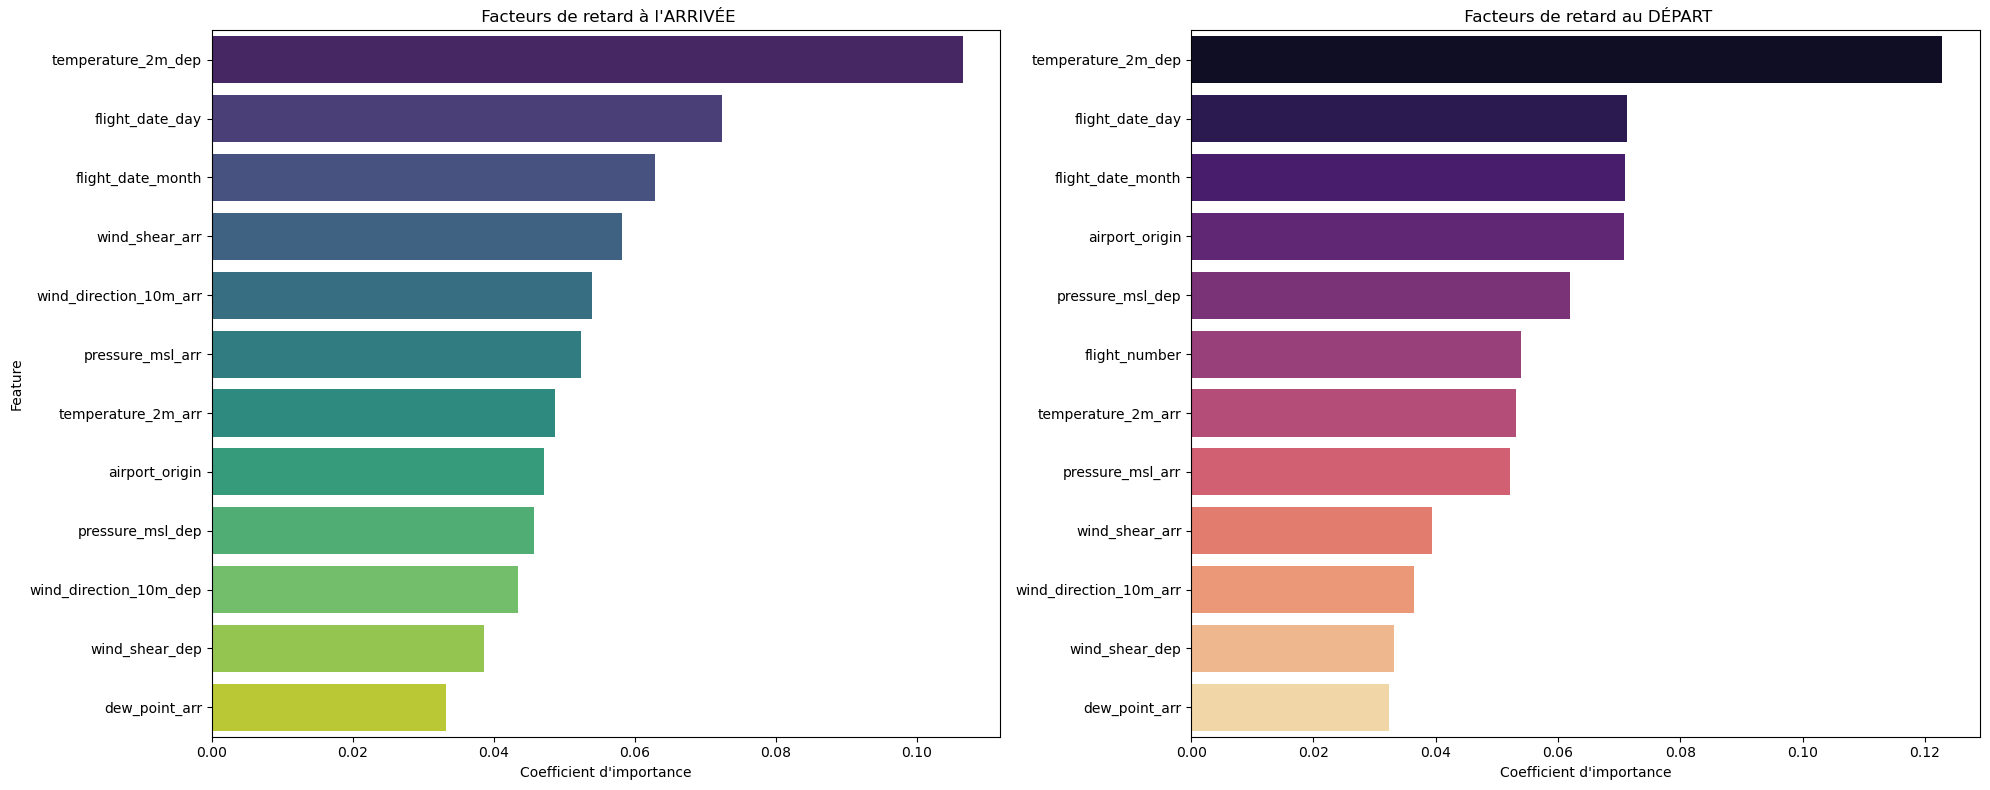

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


imp_arr = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': model_reg_arr.feature_importances_
}).sort_values(by='Importance', ascending=False).head(12)

imp_dep = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': model_reg_dep.feature_importances_
}).sort_values(by='Importance', ascending=False).head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Importance', y='Feature', data=imp_arr, palette='viridis', ax=ax1)
ax1.set_title(" Facteurs de retard à l'ARRIVÉE")
ax1.set_xlabel("Coefficient d'importance")

sns.barplot(x='Importance', y='Feature', data=imp_dep, palette='magma', ax=ax2)
ax2.set_title(" Facteurs de retard au DÉPART")
ax2.set_xlabel("Coefficient d'importance")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

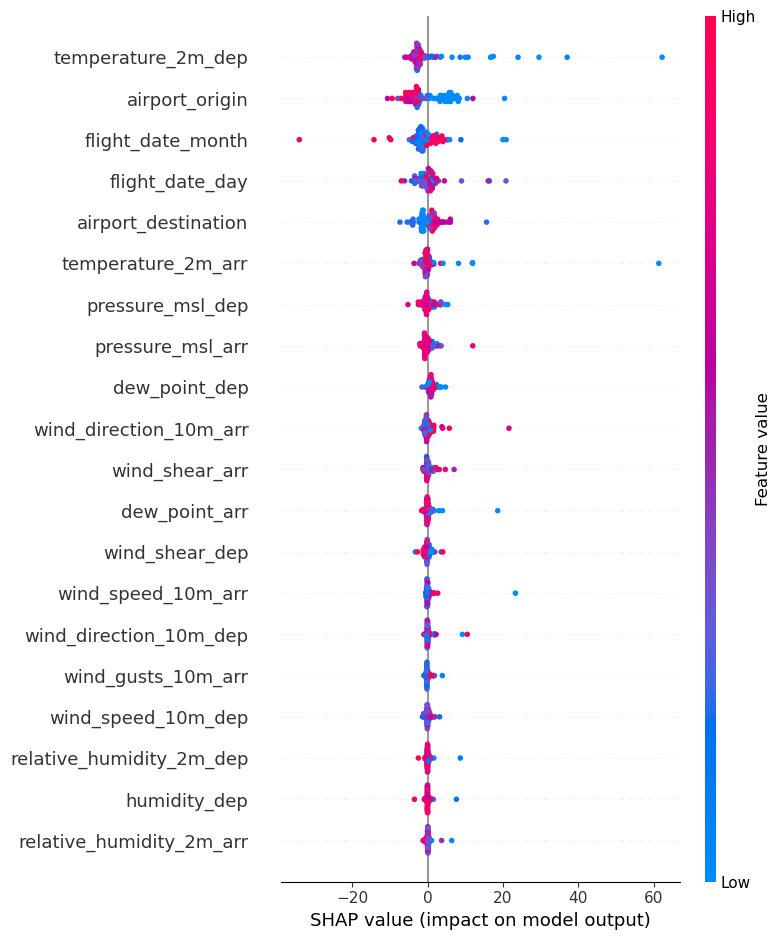

In [ ]:
import shap
explainer = shap.TreeExplainer(model_reg_arr)
shap_values = explainer.shap_values(X_test.iloc[:100])
shap.summary_plot(shap_values, X_test.iloc[:100])

# Prédire le futur

In [ ]:
df_predict_final.columns = df_predict_final.columns.str.strip()
MON_HUB = 'CDG'

X_predict = df_predict_final.copy()
for col in X_predict.columns:
    if pd.api.types.is_datetime64_any_dtype(X_predict[col]) or X_predict[col].dtype == 'object':
        try:
            temp_date = pd.to_datetime(X_predict[col], format='ISO8601', errors='coerce')
            X_predict[f"{col}_month"] = temp_date.dt.month
            X_predict[f"{col}_day"] = temp_date.dt.dayofweek
            X_predict[f"{col}_hour"] = temp_date.dt.hour
        except:
            continue

cat_cols_entrainement = list(encoder.feature_names_in_)
for col in cat_cols_entrainement:
    if col not in X_predict.columns:
        X_predict[col] = "unknown"

X_predict[cat_cols_entrainement] = encoder.transform(X_predict[cat_cols_entrainement].astype(str))
X_predict_final = X_predict.reindex(columns=X_train.columns, fill_value=-1)
X_predict_final = X_predict_final.apply(pd.to_numeric, errors='coerce').fillna(-1)

df_resultats = df_predict_final.copy()
preds_dep = model_reg_dep.predict(X_predict_final).round(1)
preds_arr = model_reg_arr.predict(X_predict_final).round(1)

df_resultats["Mouvement"] = np.where(df_resultats['airport_origin'] == MON_HUB, "🛫 DÉPART", "🛬 ARRIVÉE")
df_resultats["Retard_Prévu"] = np.where(df_resultats["Mouvement"] == "🛫 DÉPART", preds_dep, preds_arr)

col_h = [c for c in df_resultats.columns if 'scheduled_departure' in c.lower()]
if col_h:
    df_resultats["Heure"] = pd.to_datetime(df_resultats[col_h[0]], errors='coerce').dt.strftime('%H:%M')
else:
    df_resultats["Heure"] = "N/A"

df_resultats["Statut"] = np.where(df_resultats["Retard_Prévu"] > 15, "⚠️ RETARD", "✅ À L'HEURE")

cols_finales = ['Mouvement', 'flight_date', 'Heure', 'flight_number', 'Retard_Prévu', 'Statut']
cols_existantes = [c for c in cols_finales if c in df_resultats.columns]

print("✨ Pipeline terminé.")
display(df_resultats[cols_existantes].head(20))

✨ Pipeline terminé. Affichage unifié généré pour Ludo.


,Mouvement,flight_date,Heure,flight_number,Retard_Prévu,Statut
0,🛫 DÉPART,2026-04-17,N/A,AF 7300,26.2,⚠️ RETARD
1,🛬 ARRIVÉE,2026-04-17,N/A,AF 7301,4.6,✅ À L'HEURE
2,🛫 DÉPART,2026-04-17,N/A,AF 7302,24.9,⚠️ RETARD
3,🛬 ARRIVÉE,2026-04-17,N/A,AF 7303,4.5,✅ À L'HEURE
4,🛫 DÉPART,2026-04-17,N/A,AF 7304,26.1,⚠️ RETARD
5,🛬 ARRIVÉE,2026-04-17,N/A,AF 7305,5.7,✅ À L'HEURE
6,🛫 DÉPART,2026-04-17,N/A,AF 7306,26.2,⚠️ RETARD
7,🛬 ARRIVÉE,2026-04-17,N/A,AF 7307,6.2,✅ À L'HEURE
8,🛫 DÉPART,2026-04-17,N/A,AF 7308,25.8,⚠️ RETARD
9,🛬 ARRIVÉE,2026-04-17,N/A,AF 7309,5.9,✅ À L'HEURE


### VISUEL STYLE AEROPORT

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np

df_predict_final.columns = df_predict_final.columns.str.strip()

X_p = df_predict_final.copy()

for col in X_p.columns:
    if pd.api.types.is_datetime64_any_dtype(X_p[col]) or X_p[col].dtype == 'object':
        try:
            t_date = pd.to_datetime(X_p[col], format='ISO8601', errors='coerce')
            X_p[f"{col}_month"] = t_date.dt.month
            X_p[f"{col}_day"] = t_date.dt.dayofweek
            X_p[f"{col}_hour"] = t_date.dt.hour
        except: continue

c_entrainement = list(encoder.feature_names_in_)
for col in c_entrainement:
    if col not in X_p.columns:
        X_p[col] = "unknown"

X_p[c_entrainement] = encoder.transform(X_p[c_entrainement].astype(str))
X_predict_final = X_p.reindex(columns=X_train.columns, fill_value=-1)
X_predict_final = X_predict_final.apply(pd.to_numeric, errors='coerce').fillna(-1)
airports = sorted(pd.concat([df_predict_final['airport_origin'], 
                            df_predict_final['airport_destination']]).unique())

dropdown = widgets.Dropdown(
    options=airports,
    value='CDG' if 'CDG' in airports else airports[0],
    description='📍 Aéroport :',
)

def filtrer_vols(aeroport_hub):
    clear_output(wait=True)
    
    
    masque = (df_predict_final['airport_origin'] == aeroport_hub) | (df_predict_final['airport_destination'] == aeroport_hub)
    df_local = df_predict_final[masque].copy()
    X_local = X_predict_final[masque]
    
    if df_local.empty:
        print(f"📭 Aucun vol trouvé pour {aeroport_hub}")
        return

    
    df_local["retard_dep_prevu"] = model_reg_dep.predict(X_local).round(1)
    df_local["retard_arr_prevu"] = model_reg_arr.predict(X_local).round(1)

    df_local["Mouvement"] = np.where(df_local['airport_origin'] == aeroport_hub, "🛫 DÉPART", "🛬 ARRIVÉE")
    df_local.loc[df_local["Mouvement"] == "🛫 DÉPART", "retard_arr_prevu"] = np.nan
    df_local.loc[df_local["Mouvement"] == "🛬 ARRIVÉE", "retard_dep_prevu"] = np.nan

    
    c_h = [c for c in df_local.columns if 'scheduled_departure' in c.lower()]
    df_local["Heure"] = pd.to_datetime(df_local[c_h[0]], errors='coerce').dt.strftime('%H:%M') if c_h else "N/A"

    
    v_ret = df_local[["retard_dep_prevu", "retard_arr_prevu"]].fillna(0).max(axis=1)
    df_local["Statut"] = np.where(v_ret > 15, "⚠️ RETARD", "✅ À L'HEURE")

    
    cols = ['Mouvement', 'flight_date', 'Heure', 'flight_number', 'retard_dep_prevu', 'retard_arr_prevu', 'Statut']
    df_aff = df_local[[c for c in cols if c in df_local.columns]].fillna('-')
    
    print(f"\n✈️  TABLEAU D'AFFICHAGE : {aeroport_hub}")
    display(df_aff.sort_values('Heure'))


widgets.interactive(filtrer_vols, aeroport_hub=dropdown)

interactive(children=(Dropdown(description='📍 Aéroport :', options=('CDG', 'LYS', 'MRS', 'NCE', 'ORY', 'TLS'),…